In [1]:
from pathlib import Path
import sys
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    hamming_loss,
    confusion_matrix,
)

In [2]:
current = Path.cwd()

PROJECT_ROOT = None

for path in [current] + list(current.parents):

    if (path / "src").is_dir():

        PROJECT_ROOT = path

        break


if PROJECT_ROOT is None:

    raise FileNotFoundError(
        "Could not find project root containing 'src'."
    )


if str(PROJECT_ROOT) not in sys.path:

    sys.path.insert(
        0,
        str(PROJECT_ROOT)
    )


print(
    "Project root:",
    PROJECT_ROOT
)

Project root: d:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service


In [3]:
SEED = 42


def set_seed(seed=42):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():

        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)


DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print(
    "PyTorch:",
    torch.__version__
)

print(
    "Device:",
    DEVICE
)


if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

    print(
        "CUDA:",
        torch.version.cuda
    )

PyTorch: 2.14.0+cu130
Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
CUDA: 13.0


In [4]:
PREPROCESSING_VERSION = (
    "100hz_record_zscore"
)


MODEL_NAME = (
    "resnet_depth34"
)


PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "ecg"
    / "ptbxl"
    / PREPROCESSING_VERSION
)


MANIFEST_PATH = (
    PROCESSED_DIR
    / "manifests"
    / "ptbxl_manifest.csv"
)


PREPROCESSING_CONFIG_PATH = (
    PROCESSED_DIR
    / "preprocessing_config.json"
)


CHECKPOINT_DIR = (
    PROJECT_ROOT
    / "checkpoints"
    / "ecg"
    / MODEL_NAME
    / PREPROCESSING_VERSION
)


CHECKPOINT_PATH = (
    CHECKPOINT_DIR
    / "ptbxl_xresnet1d_depth34_100hz_record_zscore.pt"
)


RESULTS_DIR = (
    PROJECT_ROOT
    / "artifacts"
    / "metrics"
    / "ecg"
    / MODEL_NAME
    / PREPROCESSING_VERSION
)


RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print(
    "Processed directory:",
    PROCESSED_DIR
)

print(
    "Manifest:",
    MANIFEST_PATH
)

print(
    "Checkpoint:",
    CHECKPOINT_PATH
)

print(
    "Results directory:",
    RESULTS_DIR
)

Processed directory: d:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\data\processed\ecg\ptbxl\100hz_record_zscore
Manifest: d:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\data\processed\ecg\ptbxl\100hz_record_zscore\manifests\ptbxl_manifest.csv
Checkpoint: d:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\checkpoints\ecg\resnet_depth34\100hz_record_zscore\ptbxl_xresnet1d_depth34_100hz_record_zscore.pt
Results directory: d:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\artifacts\metrics\ecg\resnet_depth34\100hz_record_zscore


In [5]:
if not MANIFEST_PATH.exists():

    raise FileNotFoundError(
        f"Manifest not found:\n{MANIFEST_PATH}"
    )


if not PREPROCESSING_CONFIG_PATH.exists():

    raise FileNotFoundError(
        "Preprocessing configuration not found:\n"
        f"{PREPROCESSING_CONFIG_PATH}"
    )


if not CHECKPOINT_PATH.exists():

    raise FileNotFoundError(
        "Current ResNet checkpoint not found:\n"
        f"{CHECKPOINT_PATH}"
    )


print(
    "All required files found."
)

All required files found.


In [6]:
with open(
    PREPROCESSING_CONFIG_PATH,
    "r",
    encoding="utf-8",
) as f:

    preprocessing_config = json.load(f)


print(
    json.dumps(
        preprocessing_config,
        indent=2
    )
)

{
  "dataset": "PTB-XL",
  "version_name": "100hz_record_zscore",
  "random_seed": 42,
  "source_waveform": "filename_lr",
  "sampling": {
    "target_fs_hz": 100,
    "duration_seconds": 10,
    "target_length": 1000
  },
  "signal": {
    "num_leads": 12,
    "lead_names": [
      "I",
      "II",
      "III",
      "AVR",
      "AVL",
      "AVF",
      "V1",
      "V2",
      "V3",
      "V4",
      "V5",
      "V6"
    ]
  },
  "filter": {
    "enabled": true,
    "type": "butterworth_highpass",
    "cutoff_hz": 0.5,
    "order": 3,
    "zero_phase": true
  },
  "resampling": {
    "method": "scipy.signal.resample_poly"
  },
  "length_policy": {
    "mode": "strict",
    "truncate": false,
    "zero_pad": false
  },
  "normalization": {
    "mode": "train_global_zscore",
    "epsilon": 1e-08,
    "statistics_source": "train_only"
  },
  "split": {
    "train_folds": [
      1,
      2,
      3,
      4,
      5,
      6,
      7,
      8
    ],
    "validation_folds": [
      9
  

In [7]:
checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=DEVICE,
    weights_only=False,
)


print(
    "Checkpoint loaded."
)

print(
    "Checkpoint keys:"
)

print(
    list(
        checkpoint.keys()
    )
)

Checkpoint loaded.
Checkpoint keys:
['model_state_dict', 'model_config', 'train_config', 'loss_config', 'augmentation_config', 'selection_config', 'preprocessing_version', 'preprocessing_config', 'num_leads', 'signal_length', 'diagnostic_targets', 'rhythm_targets', 'diagnostic_thresholds', 'rhythm_thresholds', 'best_epoch', 'best_validation_selection_score', 'seed']


In [8]:
MODEL_CONFIG = checkpoint[
    "model_config"
]


SIGNAL_LENGTH = int(
    checkpoint[
        "signal_length"
    ]
)


NUM_LEADS = int(
    checkpoint[
        "num_leads"
    ]
)


DIAGNOSTIC_COLUMNS = list(
    checkpoint[
        "diagnostic_targets"
    ]
)


RHYTHM_COLUMNS = list(
    checkpoint[
        "rhythm_targets"
    ]
)


DIAGNOSTIC_THRESHOLDS = np.asarray(
    checkpoint[
        "diagnostic_thresholds"
    ],
    dtype=np.float32,
)


RHYTHM_THRESHOLDS = np.asarray(
    checkpoint[
        "rhythm_thresholds"
    ],
    dtype=np.float32,
)


print(
    "Model config:"
)

print(
    json.dumps(
        MODEL_CONFIG,
        indent=2
    )
)


print(
    "\nSignal length:",
    SIGNAL_LENGTH
)


print(
    "Number of leads:",
    NUM_LEADS
)


print(
    "\nDiagnostic labels:"
)

print(
    DIAGNOSTIC_COLUMNS
)


print(
    "\nRhythm labels:"
)

print(
    RHYTHM_COLUMNS
)

Model config:
{
  "name": "xresnet1d",
  "depth": 34,
  "dropout": 0.3
}

Signal length: 1000
Number of leads: 12

Diagnostic labels:
['NORM', 'MI', 'STTC', 'CD', 'HYP']

Rhythm labels:
['RHYTHM_SR', 'RHYTHM_AFIB', 'RHYTHM_AFLT', 'RHYTHM_STACH', 'RHYTHM_SBRAD', 'RHYTHM_SARRH', 'RHYTHM_PSVT', 'RHYTHM_BIGU', 'RHYTHM_PACE']


In [9]:
diagnostic_thresholds_df = pd.DataFrame({

    "label":
        DIAGNOSTIC_COLUMNS,

    "threshold":
        DIAGNOSTIC_THRESHOLDS,

})


rhythm_thresholds_df = pd.DataFrame({

    "label":
        RHYTHM_COLUMNS,

    "threshold":
        RHYTHM_THRESHOLDS,

})


print(
    "Diagnostic thresholds:"
)

display(
    diagnostic_thresholds_df
)


print(
    "Rhythm thresholds:"
)

display(
    rhythm_thresholds_df
)

Diagnostic thresholds:


,label,threshold
0,NORM,0.58
1,MI,0.23
2,STTC,0.33
3,CD,0.63
4,HYP,0.42


Rhythm thresholds:


,label,threshold
0,RHYTHM_SR,0.36
1,RHYTHM_AFIB,0.81
2,RHYTHM_AFLT,0.99
3,RHYTHM_STACH,0.89
4,RHYTHM_SBRAD,0.61
5,RHYTHM_SARRH,0.50
6,RHYTHM_PSVT,0.15
7,RHYTHM_BIGU,0.44
8,RHYTHM_PACE,0.27


In [10]:
ptbxl = pd.read_csv(
    MANIFEST_PATH
)


print(
    "Manifest shape:",
    ptbxl.shape
)


print(
    "\nColumns:"
)

print(
    ptbxl.columns.tolist()
)

Manifest shape: (21837, 25)

Columns:
['ecg_id', 'patient_id', 'record_name', 'processed_path', 'split', 'strat_fold', 'original_fs', 'original_shape', 'resampled_shape', 'final_shape', 'final_dtype', 'NORM', 'MI', 'STTC', 'CD', 'HYP', 'RHYTHM_SR', 'RHYTHM_AFIB', 'RHYTHM_AFLT', 'RHYTHM_STACH', 'RHYTHM_SBRAD', 'RHYTHM_SARRH', 'RHYTHM_PSVT', 'RHYTHM_BIGU', 'RHYTHM_PACE']


In [11]:
required_columns = [
    "processed_path",
    "patient_id",
]


for column in required_columns:

    if column not in ptbxl.columns:

        raise ValueError(
            f"Missing required column: {column}"
        )


for column in (
    DIAGNOSTIC_COLUMNS
    +
    RHYTHM_COLUMNS
):

    if column not in ptbxl.columns:

        raise ValueError(
            f"Missing target column: {column}"
        )


print(
    "All target columns verified."
)

All target columns verified.


In [12]:
train_df = (
    ptbxl[
        ptbxl["split"] == "train"
    ]
    .copy()
    .reset_index(drop=True)
)


val_df = (
    ptbxl[
        ptbxl["split"] == "val"
    ]
    .copy()
    .reset_index(drop=True)
)


test_df = (
    ptbxl[
        ptbxl["split"] == "test"
    ]
    .copy()
    .reset_index(drop=True)
)


print(
    f"Train      : {len(train_df):,}"
)

print(
    f"Validation : {len(val_df):,}"
)

print(
    f"Test       : {len(test_df):,}"
)

Train      : 17,441
Validation : 2,193
Test       : 2,203


In [13]:
train_patients = set(
    train_df["patient_id"]
)

val_patients = set(
    val_df["patient_id"]
)

test_patients = set(
    test_df["patient_id"]
)


train_val_overlap = (
    train_patients
    &
    val_patients
)


train_test_overlap = (
    train_patients
    &
    test_patients
)


val_test_overlap = (
    val_patients
    &
    test_patients
)


print(
    "Train ∩ Validation:",
    len(train_val_overlap)
)

print(
    "Train ∩ Test:",
    len(train_test_overlap)
)

print(
    "Validation ∩ Test:",
    len(val_test_overlap)
)


if (
    len(train_val_overlap) > 0
    or
    len(train_test_overlap) > 0
    or
    len(val_test_overlap) > 0
):

    raise RuntimeError(
        "Patient leakage detected."
    )


print(
    "\nPatient-level split check PASSED."
)

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0

Patient-level split check PASSED.


In [14]:
class PTBXLDataset(Dataset):

    def __init__(
        self,
        dataframe,
        project_root,
        diagnostic_targets,
        rhythm_targets,
    ):

        self.df = (
            dataframe
            .reset_index(
                drop=True
            )
        )


        self.project_root = Path(
            project_root
        )


        self.diagnostic_targets = list(
            diagnostic_targets
        )


        self.rhythm_targets = list(
            rhythm_targets
        )


    def __len__(self):

        return len(
            self.df
        )


    def __getitem__(
        self,
        index,
    ):

        row = self.df.iloc[index]


        path = (
            self.project_root
            /
            row[
                "processed_path"
            ]
        )


        signal = np.load(
            path,
            allow_pickle=False,
        )


        if signal.shape != (
            SIGNAL_LENGTH,
            NUM_LEADS,
        ):

            raise ValueError(
                f"Unexpected ECG shape "
                f"{signal.shape} at {path}. "
                f"Expected "
                f"({SIGNAL_LENGTH}, "
                f"{NUM_LEADS})."
            )


        if not np.isfinite(
            signal
        ).all():

            raise ValueError(
                f"Non-finite ECG values "
                f"at {path}."
            )


        # [time, leads]
        # →
        # [leads, time]

        signal = signal.T


        diagnostic = np.asarray(
            [
                row[column]
                for column
                in self.diagnostic_targets
            ],
            dtype=np.float32,
        )


        if self.rhythm_targets:

            rhythm = np.asarray(
                [
                    row[column]
                    for column
                    in self.rhythm_targets
                ],
                dtype=np.float32,
            )

        else:

            rhythm = np.empty(
                (0,),
                dtype=np.float32,
            )


        return (
            torch.from_numpy(
                signal.astype(
                    np.float32,
                    copy=False,
                )
            ),

            torch.from_numpy(
                diagnostic
            ),

            torch.from_numpy(
                rhythm
            ),
        )

In [15]:
test_dataset = PTBXLDataset(

    test_df,

    PROJECT_ROOT,

    DIAGNOSTIC_COLUMNS,

    RHYTHM_COLUMNS,
)


print(
    "Test dataset:",
    len(test_dataset)
)

Test dataset: 2203


In [16]:
signal, diagnostic, rhythm = (
    test_dataset[0]
)


print(
    "Signal shape:",
    signal.shape
)

print(
    "Diagnostic shape:",
    diagnostic.shape
)

print(
    "Rhythm shape:",
    rhythm.shape
)

Signal shape: torch.Size([12, 1000])
Diagnostic shape: torch.Size([5])
Rhythm shape: torch.Size([9])


In [17]:
TEST_BATCH_SIZE = 32


test_loader = DataLoader(

    test_dataset,

    batch_size=
        TEST_BATCH_SIZE,

    shuffle=False,

    num_workers=0,

    pin_memory=
        torch.cuda.is_available(),

    drop_last=False,
)


print(
    "Test batches:",
    len(test_loader)
)

Test batches: 69


In [18]:
from src.models.ecg.xresnet1d import (
    XResNet1D
)

In [19]:
model = XResNet1D(

    input_channels=
        NUM_LEADS,

    num_diagnostic_classes=
        len(
            DIAGNOSTIC_COLUMNS
        ),

    num_rhythm_classes=
        len(
            RHYTHM_COLUMNS
        ),

    depth=
        MODEL_CONFIG[
            "depth"
        ],

    dropout=
        MODEL_CONFIG[
            "dropout"
        ],
)


model = model.to(
    DEVICE
)


print(
    model
)

XResNet1D(
  (stem): Sequential(
    (0): Conv1d(12, 64, kernel_size=(7,), stride=(2,), padding=(3,), bias=False)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool1d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (layer1): Sequential(
    (0): Bottleneck1D(
      (conv1): Conv1d(64, 64, kernel_size=(1,), stride=(1,), bias=False)
      (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv1d(64, 256, kernel_size=(1,), stride=(1,), bias=False)
      (bn3): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0)

In [20]:
if (
    "model_state_dict"
    in checkpoint
):

    state_dict = checkpoint[
        "model_state_dict"
    ]

elif (
    "state_dict"
    in checkpoint
):

    state_dict = checkpoint[
        "state_dict"
    ]

else:

    state_dict = checkpoint


clean_state_dict = {}


for key, value in state_dict.items():

    new_key = key


    if new_key.startswith(
        "module."
    ):

        new_key = new_key[
            len("module.") :
        ]


    clean_state_dict[
        new_key
    ] = value


missing_keys, unexpected_keys = (
    model.load_state_dict(
        clean_state_dict,
        strict=False,
    )
)


print(
    "Missing keys:",
    missing_keys
)

print(
    "Unexpected keys:",
    unexpected_keys
)


if (
    len(missing_keys) > 0
    or
    len(unexpected_keys) > 0
):

    raise RuntimeError(
        "Model/checkpoint mismatch."
    )


model.eval()


print(
    "\nCurrent ResNet checkpoint loaded successfully."
)

Missing keys: []
Unexpected keys: []

Current ResNet checkpoint loaded successfully.


In [21]:
total_parameters = sum(
    parameter.numel()
    for parameter
    in model.parameters()
)


trainable_parameters = sum(
    parameter.numel()
    for parameter
    in model.parameters()
    if parameter.requires_grad
)


print(
    "Total parameters:",
    f"{total_parameters:,}"
)


print(
    "Trainable parameters:",
    f"{trainable_parameters:,}"
)

Total parameters: 11,185,550
Trainable parameters: 11,185,550


In [22]:
@torch.no_grad()
def collect_test_predictions(
    model,
    loader,
):

    model.eval()


    diagnostic_true = []

    diagnostic_probs = []


    rhythm_true = []

    rhythm_probs = []


    for (
        signals,
        diagnostic,
        rhythm,
    ) in loader:


        signals = signals.to(
            DEVICE,
            non_blocking=True,
        )


        diagnostic = diagnostic.to(
            DEVICE,
            non_blocking=True,
        )


        rhythm = rhythm.to(
            DEVICE,
            non_blocking=True,
        )


        outputs = model(
            signals
        )


        diagnostic_probability = (
            torch.sigmoid(
                outputs[
                    "diagnostic"
                ]
            )
            .cpu()
            .numpy()
        )


        diagnostic_true.append(
            diagnostic
            .cpu()
            .numpy()
        )


        diagnostic_probs.append(
            diagnostic_probability
        )


        if len(
            RHYTHM_COLUMNS
        ) > 0:

            rhythm_probability = (
                torch.sigmoid(
                    outputs[
                        "rhythm"
                    ]
                )
                .cpu()
                .numpy()
            )


            rhythm_true.append(
                rhythm
                .cpu()
                .numpy()
            )


            rhythm_probs.append(
                rhythm_probability
            )


    result = {

        "diagnostic_true":
            np.concatenate(
                diagnostic_true,
                axis=0,
            ),

        "diagnostic_probs":
            np.concatenate(
                diagnostic_probs,
                axis=0,
            ),
    }


    if rhythm_true:

        result[
            "rhythm_true"
        ] = np.concatenate(
            rhythm_true,
            axis=0,
        )


        result[
            "rhythm_probs"
        ] = np.concatenate(
            rhythm_probs,
            axis=0,
        )


    return result


test_outputs = (
    collect_test_predictions(
        model,
        test_loader,
    )
)


diagnostic_true = (
    test_outputs[
        "diagnostic_true"
    ]
)


diagnostic_probs = (
    test_outputs[
        "diagnostic_probs"
    ]
)


rhythm_true = (
    test_outputs[
        "rhythm_true"
    ]
)


rhythm_probs = (
    test_outputs[
        "rhythm_probs"
    ]
)


print(
    "Diagnostic true:",
    diagnostic_true.shape
)


print(
    "Diagnostic probabilities:",
    diagnostic_probs.shape
)


print(
    "Rhythm true:",
    rhythm_true.shape
)


print(
    "Rhythm probabilities:",
    rhythm_probs.shape
)

Diagnostic true: (2203, 5)
Diagnostic probabilities: (2203, 5)
Rhythm true: (2203, 9)
Rhythm probabilities: (2203, 9)


In [23]:
diagnostic_pred = (
    diagnostic_probs
    >=
    DIAGNOSTIC_THRESHOLDS
).astype(int)


rhythm_pred = (
    rhythm_probs
    >=
    RHYTHM_THRESHOLDS
).astype(int)


print(
    "Diagnostic predictions:",
    diagnostic_pred.shape
)


print(
    "Rhythm predictions:",
    rhythm_pred.shape
)

Diagnostic predictions: (2203, 5)
Rhythm predictions: (2203, 9)


In [24]:
def macro_auroc(
    y_true,
    y_prob,
):

    scores = []


    for i in range(
        y_true.shape[1]
    ):

        if (
            len(
                np.unique(
                    y_true[:, i]
                )
            )
            < 2
        ):

            continue


        scores.append(
            roc_auc_score(
                y_true[:, i],
                y_prob[:, i],
            )
        )


    return float(
        np.mean(scores)
    )


def macro_auprc(
    y_true,
    y_prob,
):

    scores = []


    for i in range(
        y_true.shape[1]
    ):

        scores.append(
            average_precision_score(
                y_true[:, i],
                y_prob[:, i],
            )
        )


    return float(
        np.mean(scores)
    )

In [25]:
def calculate_metrics(
    y_true,
    y_prob,
    y_pred,
):

    return {

        "AUROC":
            macro_auroc(
                y_true,
                y_prob,
            ),

        "AUPRC":
            macro_auprc(
                y_true,
                y_prob,
            ),

        "Macro F1":
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            ),

        "Micro F1":
            f1_score(
                y_true,
                y_pred,
                average="micro",
                zero_division=0,
            ),

        "Macro Precision":
            precision_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            ),

        "Macro Recall":
            recall_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            ),

        # Complete label vector must match
        "Exact Match Accuracy":
            accuracy_score(
                y_true,
                y_pred,
            ),

        # Individual labels
        "Hamming Accuracy":
            1.0
            -
            hamming_loss(
                y_true,
                y_pred,
            ),
    }

In [26]:
diagnostic_metrics = (
    calculate_metrics(

        diagnostic_true,

        diagnostic_probs,

        diagnostic_pred,
    )
)


print(
    "=" * 75
)

print(
    "FINAL RESNET DIAGNOSTIC TEST RESULTS"
)

print(
    "=" * 75
)


for key, value in (
    diagnostic_metrics.items()
):

    print(
        f"{key:<25}: "
        f"{value:.6f}"
    )

FINAL RESNET DIAGNOSTIC TEST RESULTS
AUROC                    : 0.922165
AUPRC                    : 0.803364
Macro F1                 : 0.735125
Micro F1                 : 0.763019
Macro Precision          : 0.681304
Macro Recall             : 0.801304
Exact Match Accuracy     : 0.566500
Hamming Accuracy         : 0.869451


In [27]:
rhythm_metrics = (
    calculate_metrics(

        rhythm_true,

        rhythm_probs,

        rhythm_pred,
    )
)


print(
    "=" * 75
)

print(
    "FINAL RESNET RHYTHM TEST RESULTS"
)

print(
    "=" * 75
)


for key, value in (
    rhythm_metrics.items()
):

    print(
        f"{key:<25}: "
        f"{value:.6f}"
    )

FINAL RESNET RHYTHM TEST RESULTS
AUROC                    : 0.952629
AUPRC                    : 0.594313
Macro F1                 : 0.582287
Micro F1                 : 0.873462
Macro Precision          : 0.642732
Macro Recall             : 0.596289
Exact Match Accuracy     : 0.826146
Hamming Accuracy         : 0.972512


In [28]:
comparison_df = pd.DataFrame(

    [

        {
            "Task":
                "Diagnostic",

            "AUROC":
                diagnostic_metrics[
                    "AUROC"
                ],

            "AUPRC":
                diagnostic_metrics[
                    "AUPRC"
                ],

            "Macro F1":
                diagnostic_metrics[
                    "Macro F1"
                ],

            "Precision":
                diagnostic_metrics[
                    "Macro Precision"
                ],

            "Recall":
                diagnostic_metrics[
                    "Macro Recall"
                ],

            "Exact Match Accuracy":
                diagnostic_metrics[
                    "Exact Match Accuracy"
                ],

            "Hamming Accuracy":
                diagnostic_metrics[
                    "Hamming Accuracy"
                ],
        },


        {
            "Task":
                "Rhythm",

            "AUROC":
                rhythm_metrics[
                    "AUROC"
                ],

            "AUPRC":
                rhythm_metrics[
                    "AUPRC"
                ],

            "Macro F1":
                rhythm_metrics[
                    "Macro F1"
                ],

            "Precision":
                rhythm_metrics[
                    "Macro Precision"
                ],

            "Recall":
                rhythm_metrics[
                    "Macro Recall"
                ],

            "Exact Match Accuracy":
                rhythm_metrics[
                    "Exact Match Accuracy"
                ],

            "Hamming Accuracy":
                rhythm_metrics[
                    "Hamming Accuracy"
                ],
        },

    ]
)


display(
    comparison_df
)

,Task,AUROC,AUPRC,Macro F1,Precision,Recall,Exact Match Accuracy,Hamming Accuracy
0,Diagnostic,0.922165,0.803364,0.735125,0.681304,0.801304,0.566500,0.869451
1,Rhythm,0.952629,0.594313,0.582287,0.642732,0.596289,0.826146,0.972512


In [29]:
diagnostic_rows = []


for i, label in enumerate(
    DIAGNOSTIC_COLUMNS
):

    true = diagnostic_true[
        :, i
    ]


    prob = diagnostic_probs[
        :, i
    ]


    pred = diagnostic_pred[
        :, i
    ]


    if len(
        np.unique(true)
    ) >= 2:

        auroc = (
            roc_auc_score(
                true,
                prob,
            )
        )


        auprc = (
            average_precision_score(
                true,
                prob,
            )
        )

    else:

        auroc = np.nan

        auprc = np.nan


    tn, fp, fn, tp = (
        confusion_matrix(
            true,
            pred,
            labels=[0, 1],
        )
        .ravel()
    )


    diagnostic_rows.append({

        "Label":
            label,

        "AUROC":
            auroc,

        "AUPRC":
            auprc,

        "F1":
            f1_score(
                true,
                pred,
                zero_division=0,
            ),

        "Precision":
            precision_score(
                true,
                pred,
                zero_division=0,
            ),

        "Recall":
            recall_score(
                true,
                pred,
                zero_division=0,
            ),

        "Accuracy":
            accuracy_score(
                true,
                pred,
            ),

        "Specificity":
            (
                tn
                /
                (tn + fp)
                if (tn + fp) > 0
                else np.nan
            ),

        "TP":
            tp,

        "FP":
            fp,

        "FN":
            fn,

        "TN":
            tn,
    })


diagnostic_report = pd.DataFrame(
    diagnostic_rows
)


display(
    diagnostic_report
)

,Label,AUROC,AUPRC,F1,Precision,Recall,Accuracy,Specificity,TP,FP,FN,TN
0,NORM,0.946070,0.922900,0.857848,0.818267,0.901452,0.869269,0.844229,869,193,95,1046
1,MI,0.912790,0.808309,0.717907,0.655224,0.793852,0.843395,0.860000,439,231,114,1419
2,STTC,0.929240,0.800856,0.739635,0.653001,0.852772,0.857467,0.858929,446,237,77,1443
3,CD,0.912350,0.818179,0.739430,0.724470,0.755020,0.879709,0.916129,376,143,122,1562
4,HYP,0.910376,0.666577,0.620805,0.555556,0.703422,0.897413,0.923711,185,148,78,1792


In [30]:
rhythm_rows = []


for i, label in enumerate(
    RHYTHM_COLUMNS
):

    true = rhythm_true[
        :, i
    ]


    prob = rhythm_probs[
        :, i
    ]


    pred = rhythm_pred[
        :, i
    ]


    if len(
        np.unique(true)
    ) >= 2:

        auroc = (
            roc_auc_score(
                true,
                prob,
            )
        )


        auprc = (
            average_precision_score(
                true,
                prob,
            )
        )

    else:

        auroc = np.nan

        auprc = np.nan


    tn, fp, fn, tp = (
        confusion_matrix(
            true,
            pred,
            labels=[0, 1],
        )
        .ravel()
    )


    rhythm_rows.append({

        "Label":
            label,

        "AUROC":
            auroc,

        "AUPRC":
            auprc,

        "F1":
            f1_score(
                true,
                pred,
                zero_division=0,
            ),

        "Precision":
            precision_score(
                true,
                pred,
                zero_division=0,
            ),

        "Recall":
            recall_score(
                true,
                pred,
                zero_division=0,
            ),

        "Accuracy":
            accuracy_score(
                true,
                pred,
            ),

        "Specificity":
            (
                tn
                /
                (tn + fp)
                if (tn + fp) > 0
                else np.nan
            ),

        "TP":
            tp,

        "FP":
            fp,

        "FN":
            fn,

        "TN":
            tn,
    })


rhythm_report = pd.DataFrame(
    rhythm_rows
)


display(
    rhythm_report
)

,Label,AUROC,AUPRC,F1,Precision,Recall,Accuracy,Specificity,TP,FP,FN,TN
0,RHYTHM_SR,0.895204,0.953173,0.923475,0.892659,0.956496,0.879256,0.632381,1605,193,73,332
1,RHYTHM_AFIB,0.979586,0.917889,0.838284,0.841060,0.835526,0.977758,0.988298,127,24,25,2027
2,RHYTHM_AFLT,0.970336,0.514759,0.600000,1.000000,0.428571,0.998184,1.000000,3,0,4,2196
3,RHYTHM_STACH,0.993969,0.891047,0.838323,0.823529,0.853659,0.987744,0.992928,70,15,12,2106
4,RHYTHM_SBRAD,0.958151,0.563299,0.538462,0.700000,0.437500,0.978212,0.994390,28,12,36,2127
5,RHYTHM_SARRH,0.882671,0.258766,0.312500,0.301205,0.324675,0.950068,0.972719,25,58,52,2068
6,RHYTHM_PSVT,0.995229,0.138889,0.111111,0.062500,0.500000,0.992737,0.993185,1,15,1,2186
7,RHYTHM_BIGU,0.970444,0.400272,0.333333,0.300000,0.375000,0.994553,0.996811,3,7,5,2188
8,RHYTHM_PACE,0.928068,0.710728,0.745098,0.863636,0.655172,0.994099,0.998620,19,3,10,2171


In [31]:
display(
    diagnostic_report.sort_values(
        "F1",
        ascending=False,
    ).reset_index(
        drop=True
    )
)

,Label,AUROC,AUPRC,F1,Precision,Recall,Accuracy,Specificity,TP,FP,FN,TN
0,NORM,0.946070,0.922900,0.857848,0.818267,0.901452,0.869269,0.844229,869,193,95,1046
1,STTC,0.929240,0.800856,0.739635,0.653001,0.852772,0.857467,0.858929,446,237,77,1443
2,CD,0.912350,0.818179,0.739430,0.724470,0.755020,0.879709,0.916129,376,143,122,1562
3,MI,0.912790,0.808309,0.717907,0.655224,0.793852,0.843395,0.860000,439,231,114,1419
4,HYP,0.910376,0.666577,0.620805,0.555556,0.703422,0.897413,0.923711,185,148,78,1792


In [32]:
display(
    rhythm_report.sort_values(
        "F1",
        ascending=False,
    ).reset_index(
        drop=True
    )
)

,Label,AUROC,AUPRC,F1,Precision,Recall,Accuracy,Specificity,TP,FP,FN,TN
0,RHYTHM_SR,0.895204,0.953173,0.923475,0.892659,0.956496,0.879256,0.632381,1605,193,73,332
1,RHYTHM_STACH,0.993969,0.891047,0.838323,0.823529,0.853659,0.987744,0.992928,70,15,12,2106
2,RHYTHM_AFIB,0.979586,0.917889,0.838284,0.841060,0.835526,0.977758,0.988298,127,24,25,2027
3,RHYTHM_PACE,0.928068,0.710728,0.745098,0.863636,0.655172,0.994099,0.998620,19,3,10,2171
4,RHYTHM_AFLT,0.970336,0.514759,0.600000,1.000000,0.428571,0.998184,1.000000,3,0,4,2196
5,RHYTHM_SBRAD,0.958151,0.563299,0.538462,0.700000,0.437500,0.978212,0.994390,28,12,36,2127
6,RHYTHM_BIGU,0.970444,0.400272,0.333333,0.300000,0.375000,0.994553,0.996811,3,7,5,2188
7,RHYTHM_SARRH,0.882671,0.258766,0.312500,0.301205,0.324675,0.950068,0.972719,25,58,52,2068
8,RHYTHM_PSVT,0.995229,0.138889,0.111111,0.062500,0.500000,0.992737,0.993185,1,15,1,2186


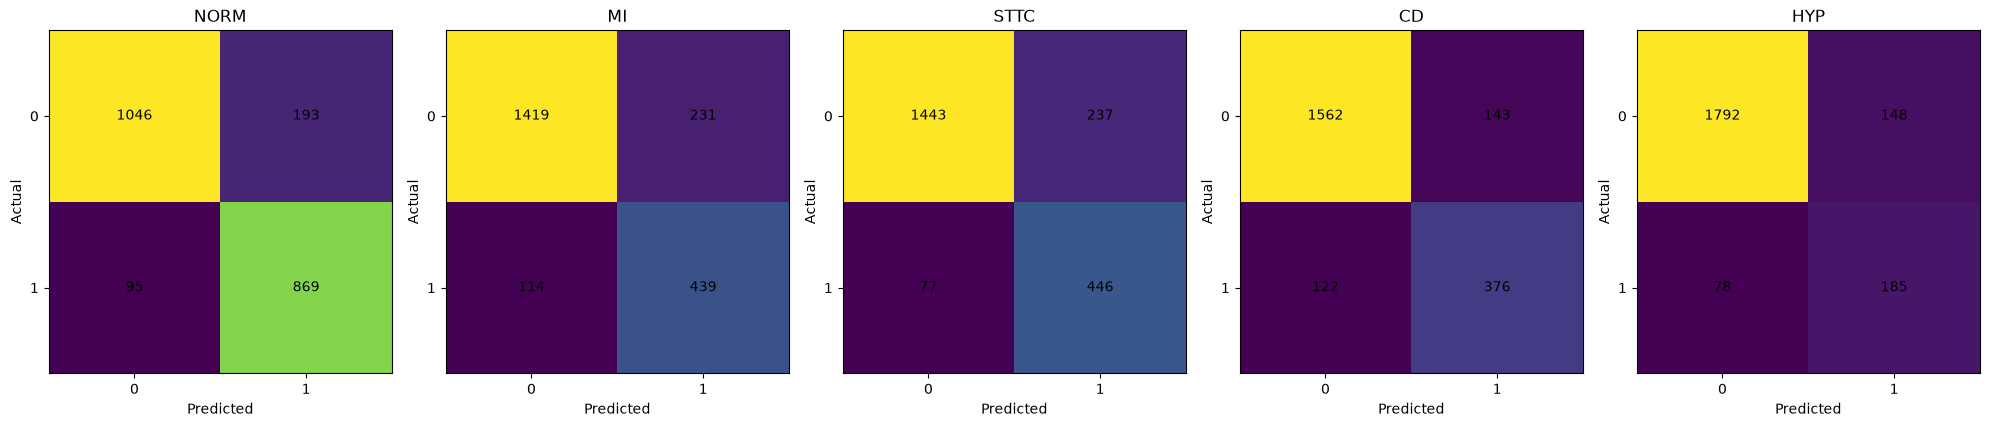

In [33]:
fig, axes = plt.subplots(
    1,
    len(DIAGNOSTIC_COLUMNS),
    figsize=(
        4 * len(DIAGNOSTIC_COLUMNS),
        4,
    ),
)


if len(
    DIAGNOSTIC_COLUMNS
) == 1:

    axes = [axes]


for ax, label, i in zip(
    axes,
    DIAGNOSTIC_COLUMNS,
    range(
        len(DIAGNOSTIC_COLUMNS)
    ),
):

    cm = confusion_matrix(

        diagnostic_true[:, i],

        diagnostic_pred[:, i],

        labels=[0, 1],
    )


    ax.imshow(cm)


    ax.set_title(
        label
    )


    ax.set_xlabel(
        "Predicted"
    )


    ax.set_ylabel(
        "Actual"
    )


    ax.set_xticks(
        [0, 1]
    )


    ax.set_yticks(
        [0, 1]
    )


    for row in range(2):

        for col in range(2):

            ax.text(
                col,
                row,
                cm[row, col],
                ha="center",
                va="center",
            )


plt.tight_layout()

plt.show()

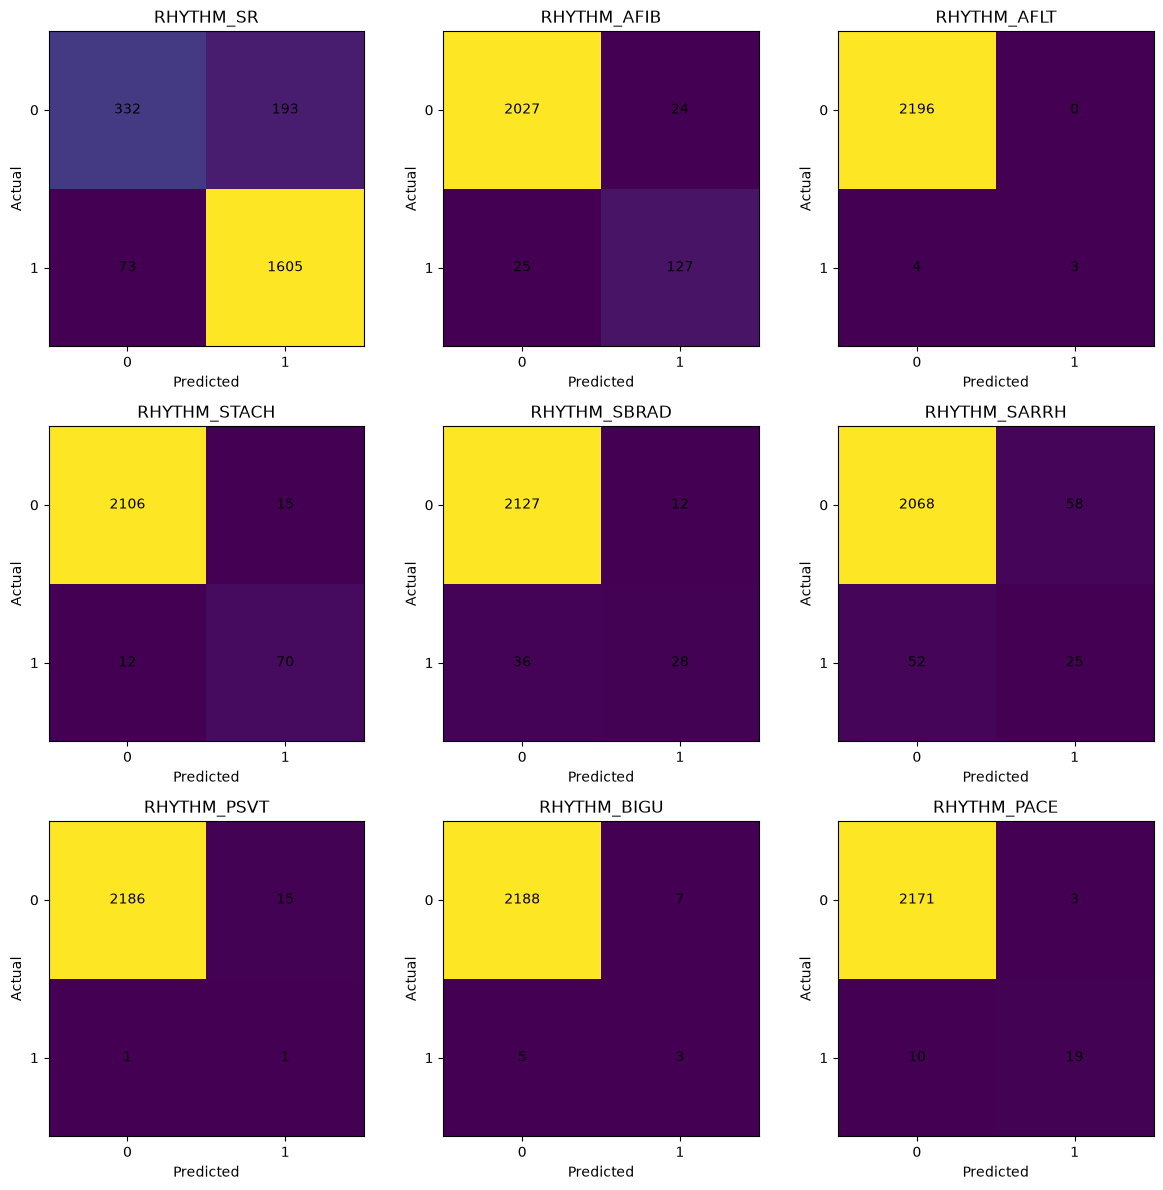

In [34]:
fig, axes = plt.subplots(
    3,
    3,
    figsize=(12, 12),
)


axes = axes.flatten()


for ax, label, i in zip(
    axes,
    RHYTHM_COLUMNS,
    range(
        len(RHYTHM_COLUMNS)
    ),
):

    cm = confusion_matrix(

        rhythm_true[:, i],

        rhythm_pred[:, i],

        labels=[0, 1],
    )


    ax.imshow(cm)


    ax.set_title(
        label
    )


    ax.set_xlabel(
        "Predicted"
    )


    ax.set_ylabel(
        "Actual"
    )


    ax.set_xticks(
        [0, 1]
    )


    ax.set_yticks(
        [0, 1]
    )


    for row in range(2):

        for col in range(2):

            ax.text(
                col,
                row,
                cm[row, col],
                ha="center",
                va="center",
            )


plt.tight_layout()

plt.show()

In [35]:
diagnostic_report_path = (
    RESULTS_DIR
    /
    "test_diagnostic_per_label.csv"
)


diagnostic_report.to_csv(
    diagnostic_report_path,
    index=False,
)


print(
    "Saved:"
)

print(
    diagnostic_report_path
)

Saved:
d:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\artifacts\metrics\ecg\resnet_depth34\100hz_record_zscore\test_diagnostic_per_label.csv


In [36]:
rhythm_report_path = (
    RESULTS_DIR
    /
    "test_rhythm_per_label.csv"
)


rhythm_report.to_csv(
    rhythm_report_path,
    index=False,
)


print(
    "Saved:"
)

print(
    rhythm_report_path
)

Saved:
d:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\artifacts\metrics\ecg\resnet_depth34\100hz_record_zscore\test_rhythm_per_label.csv


In [37]:
summary_df = pd.DataFrame(

    [

        {
            "Task":
                "Diagnostic",

            **diagnostic_metrics,
        },


        {
            "Task":
                "Rhythm",

            **rhythm_metrics,
        },

    ]
)


summary_path = (
    RESULTS_DIR
    /
    "test_summary.csv"
)


summary_df.to_csv(
    summary_path,
    index=False,
)


display(
    summary_df
)


print(
    "\nSaved:"
)

print(
    summary_path
)

,Task,AUROC,AUPRC,Macro F1,Micro F1,Macro Precision,Macro Recall,Exact Match Accuracy,Hamming Accuracy
0,Diagnostic,0.922165,0.803364,0.735125,0.763019,0.681304,0.801304,0.566500,0.869451
1,Rhythm,0.952629,0.594313,0.582287,0.873462,0.642732,0.596289,0.826146,0.972512



Saved:
d:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\artifacts\metrics\ecg\resnet_depth34\100hz_record_zscore\test_summary.csv


In [38]:
prediction_rows = []


for i in range(
    len(test_df)
):

    row = {

        "ecg_id":
            test_df.iloc[i][
                "ecg_id"
            ]
        if "ecg_id"
        in test_df.columns
        else i,

        "patient_id":
            test_df.iloc[i][
                "patient_id"
            ],

        "processed_path":
            test_df.iloc[i][
                "processed_path"
            ],
    }


    for j, label in enumerate(
        DIAGNOSTIC_COLUMNS
    ):

        row[
            f"{label}_true"
        ] = diagnostic_true[
            i, j
        ]


        row[
            f"{label}_prob"
        ] = diagnostic_probs[
            i, j
        ]


        row[
            f"{label}_pred"
        ] = diagnostic_pred[
            i, j
        ]


    for j, label in enumerate(
        RHYTHM_COLUMNS
    ):

        row[
            f"{label}_true"
        ] = rhythm_true[
            i, j
        ]


        row[
            f"{label}_prob"
        ] = rhythm_probs[
            i, j
        ]


        row[
            f"{label}_pred"
        ] = rhythm_pred[
            i, j
        ]


    prediction_rows.append(
        row
    )


predictions_df = pd.DataFrame(
    prediction_rows
)


predictions_path = (
    RESULTS_DIR
    /
    "test_predictions.csv"
)


predictions_df.to_csv(
    predictions_path,
    index=False,
)


print(
    "Saved:"
)

print(
    predictions_path
)

Saved:
d:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\artifacts\metrics\ecg\resnet_depth34\100hz_record_zscore\test_predictions.csv


In [39]:
print(
    "=" * 75
)

print(
    "FINAL EVALUATION SANITY CHECK"
)

print(
    "=" * 75
)


print(
    "Model:",
    MODEL_NAME
)


print(
    "Depth:",
    MODEL_CONFIG[
        "depth"
    ]
)


print(
    "Preprocessing:",
    PREPROCESSING_VERSION
)


print(
    "Leads:",
    NUM_LEADS
)


print(
    "Signal length:",
    SIGNAL_LENGTH
)


print(
    "Test records:",
    len(test_dataset)
)


print(
    "Diagnostic outputs:",
    diagnostic_probs.shape[1]
)


print(
    "Rhythm outputs:",
    rhythm_probs.shape[1]
)


print(
    "\nCheckpoint:"
)

print(
    CHECKPOINT_PATH
)


print(
    "\nExpected current test size: 2203"
)


if len(test_dataset) != 2203:

    raise RuntimeError(
        "Unexpected test-set size. "
        "This may indicate you are using "
        "the wrong preprocessing/manifest."
    )


print(
    "\nALL CHECKS PASSED."
)

FINAL EVALUATION SANITY CHECK
Model: resnet_depth34
Depth: 34
Preprocessing: 100hz_record_zscore
Leads: 12
Signal length: 1000
Test records: 2203
Diagnostic outputs: 5
Rhythm outputs: 9

Checkpoint:
d:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\checkpoints\ecg\resnet_depth34\100hz_record_zscore\ptbxl_xresnet1d_depth34_100hz_record_zscore.pt

Expected current test size: 2203

ALL CHECKS PASSED.
